# Part 3 — Making the Wavelet Earn Its Place

### A causal multiscale representation vs. the hand-crafted scales of HAR-RV

**Ahmet Kaçmaz**

---

Part 2 ended with an uncomfortable verdict: the wavelet + LSTM stack added nothing measurable
over a plain ARFIMA. But that experiment convicts a *particular use* of the wavelet, not the
wavelet itself. The Part 2 design had three self-inflicted handicaps:

1. **The wrong transform.** The decimated DWT is shift-*variant* and downsamples, so making it
   causal required recomputing a full decomposition on a 256-day trailing window *every day* —
   expensive, boundary-effect-prone, and dependent on an arbitrary window length.
2. **The wrong signal.** The wavelets were pointed at the *ARFIMA residual* — the part of the
   series from which the linear long-memory structure had already been removed. Multiscale
   structure lives in the level of volatility, not in what is left after you subtract it.
3. **The wrong learner.** Five separate LSTMs, each seeing one scale in isolation, fed into a
   forest. High variance, no cross-scale view, and (as Part 2 measured) seed noise comparable to
   any signal.

The forecasting literature has recommended something else all along (Renaud, Starck & Murtagh,
2005): the **causal Haar à trous transform** — undecimated, shift-invariant, causal *by
construction* — with a **simple regression on the multiscale components**.

This matters because the benchmark it challenges is itself a multiscale model. **HAR-RV**
(Corsi, 2009) regresses tomorrow's volatility on averages over the last 1, 5 and 22 days —
three time scales *picked by hand*. A wavelet decomposition derives its scales instead of
guessing them. So Part 3 asks one sharp question, with controls:

> **Is the wavelet's derived multiscale basis at least as good as HAR's hand-picked one —
> and does its advantage grow where multiscale structure should matter most: longer horizons
> and other markets?**

The comparison is designed to be fair before it is run:

- **Same estimator everywhere** (OLS) — so the contest is between *representations*, not learners.
- **A flexibility-matched control**: WaveHAR uses 6 features, so I also fit an extended HAR with
  6 features (extra lags). If WaveHAR wins only because 6 > 3, the control will say so.
- **HAC Diebold–Mariano tests** (Newey–West variance, Harvey small-sample correction) — required
  at multi-day horizons, where overlapping forecast errors are autocorrelated by construction.
- **Five additional indices** (Dow, NASDAQ, DAX, FTSE, Nikkei), because one index on one sample
  proves nothing.

Everything from Parts 1–2 still applies: no `.fit()` inside prediction, no feature for day *t*
touches day *t+1*, causality is *tested* rather than asserted, and the conclusions at the end are
**printed from the computed results**, not typed into the markdown.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import t as t_dist

SEED = 0
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

## 1. Data

Same construction as Part 2 — Garman–Klass realized volatility from daily OHLC, modeled in logs —
now wrapped in a loader that handles the data-quality quirks of non-US indices (zero-range bars on
half-holidays, occasional non-positive GK values). Cleaning counts are reported per asset.

In [2]:
ASSETS = {
    "S&P 500": "gspc", "Dow Jones": "dji", "NASDAQ": "ixic",
    "DAX": "gdaxi", "FTSE 100": "ftse", "Nikkei 225": "n225",
}

TEST_FRAC = 0.2
K_FRAC = 100          # truncation of the fractional filter
J = 5                 # à trous levels: details at ~2,4,8,16,32 days + smooth
FIRST = 128           # first usable origin (covers K_FRAC, HAR's 22 lags, à trous burn-in)


def load_asset(key):
    df = pd.read_csv(f"../data/{key}.csv", index_col="Date", parse_dates=True)
    n_raw = len(df)
    ok = (df["High"] > df["Low"]) & (df[["Open", "High", "Low", "Close"]] > 0).all(axis=1)
    df = df[ok]
    O, H, L, C = (np.array(df[k].to_numpy(), float) for k in ("Open", "High", "Low", "Close"))
    gk = 0.5 * np.log(H / L) ** 2 - (2 * np.log(2) - 1) * np.log(C / O) ** 2
    pos = gk > 0
    df, gk, C = df[pos], gk[pos], C[pos]
    r = np.diff(np.log(C))
    lrv = 0.5 * np.log(gk)[1:]            # log realized vol, aligned with r
    dates = df.index[1:]
    return dict(dates=dates, r=r, lrv=lrv, split=int(len(lrv) * (1 - TEST_FRAC)),
                dropped=n_raw - len(df))


spx = load_asset("gspc")
lrv, r, split, dates = spx["lrv"], spx["r"], spx["split"], spx["dates"]
T = len(lrv)

print(f"{'asset':<12} {'days':>6} {'dropped':>8}   train/test")
for name, key in ASSETS.items():
    a = load_asset(key)
    print(f"{name:<12} {len(a['lrv']):>6} {a['dropped']:>8}   "
          f"{a['dates'][0].date()} → {a['dates'][a['split']-1].date()} | "
          f"→ {a['dates'][-1].date()}")

asset          days  dropped   train/test
S&P 500        3521        0   2010-01-05 → 2021-03-12 | → 2023-12-29
Dow Jones      3521        0   2010-01-05 → 2021-03-12 | → 2023-12-29
NASDAQ         3521        0   2010-01-05 → 2021-03-12 | → 2023-12-29
DAX            3551        0   2010-01-05 → 2021-03-22 | → 2023-12-29
FTSE 100       3531        0   2010-01-05 → 2021-03-09 | → 2023-12-29
Nikkei 225     3423        1   2010-01-05 → 2021-03-17 | → 2023-12-29


## 2. The right transform: the causal Haar à trous

One recursion, applied level by level:

$$c_{j+1}[t] = \tfrac12\left(c_j[t] + c_j[t - 2^j]\right), \qquad
  w_{j+1}[t] = c_j[t] - c_{j+1}[t], \qquad c_0 = x$$

Each smoothing step averages the present with a point $2^j$ days in the **past** — never the
future — so the transform is causal *by construction*, not by trailing-window surgery. Three
properties the Part 2 transform lacked:

| | Part 2 (trailing-window DWT) | Part 3 (Haar à trous) |
|---|---|---|
| causality | imposed by recomputation | structural |
| shift-invariance | no (decimated) | yes (undecimated) |
| cost | $O(T \cdot W \cdot J)$ | $O(T \cdot J)$ |
| hyperparameters | window length $W = 256$ | none (just depth $J$) |
| reconstruction | approximate at boundaries | **exact**: $x[t] = c_J[t] + \sum_j w_j[t]$ |

With $J = 5$: details at characteristic scales of ~2, 4, 8, 16 and 32 trading days, plus a smooth
trend — a superset of HAR's day/week/month grid, derived instead of hand-picked.

In [3]:
def haar_atrous(x, levels=J):
    """Causal Haar à trous transform. Returns columns [w1..wJ, cJ]; row t uses only x[:t+1]."""
    x = np.asarray(x, float)
    c = x.copy()
    cols = []
    for j in range(levels):
        lag = 2 ** j
        c_next = c.copy()
        c_next[lag:] = 0.5 * (c[lag:] + c[:-lag])
        cols.append(c - c_next)
        c = c_next
    cols.append(c)
    return np.column_stack(cols)


COMP_NAMES = [f"w{j+1} (~{2**(j+1)}d)" for j in range(J)] + [f"c{J} (>~{2**J}d)"]
comps = haar_atrous(lrv)

# exact reconstruction
recon_err = np.max(np.abs(comps.sum(axis=1) - lrv))
print(f"reconstruction: max |Σ components − x| = {recon_err:.2e}   "
      f"{'PASS' if recon_err < 1e-10 else 'FAIL'}")

# causality: destroy the future, assert the past does not move
t_chk = 2000
corrupted = lrv.copy()
corrupted[t_chk + 1:] = 999.0
delta = np.max(np.abs(haar_atrous(corrupted)[:t_chk + 1] - comps[:t_chk + 1]))
print(f"causality     : max change up to day {t_chk} after destroying every later day = "
      f"{delta:.2e}   {'PASS' if delta < 1e-12 else 'FAIL'}")

reconstruction: max |Σ components − x| = 0.00e+00   PASS
causality     : max change up to day 2000 after destroying every later day = 0.00e+00   PASS


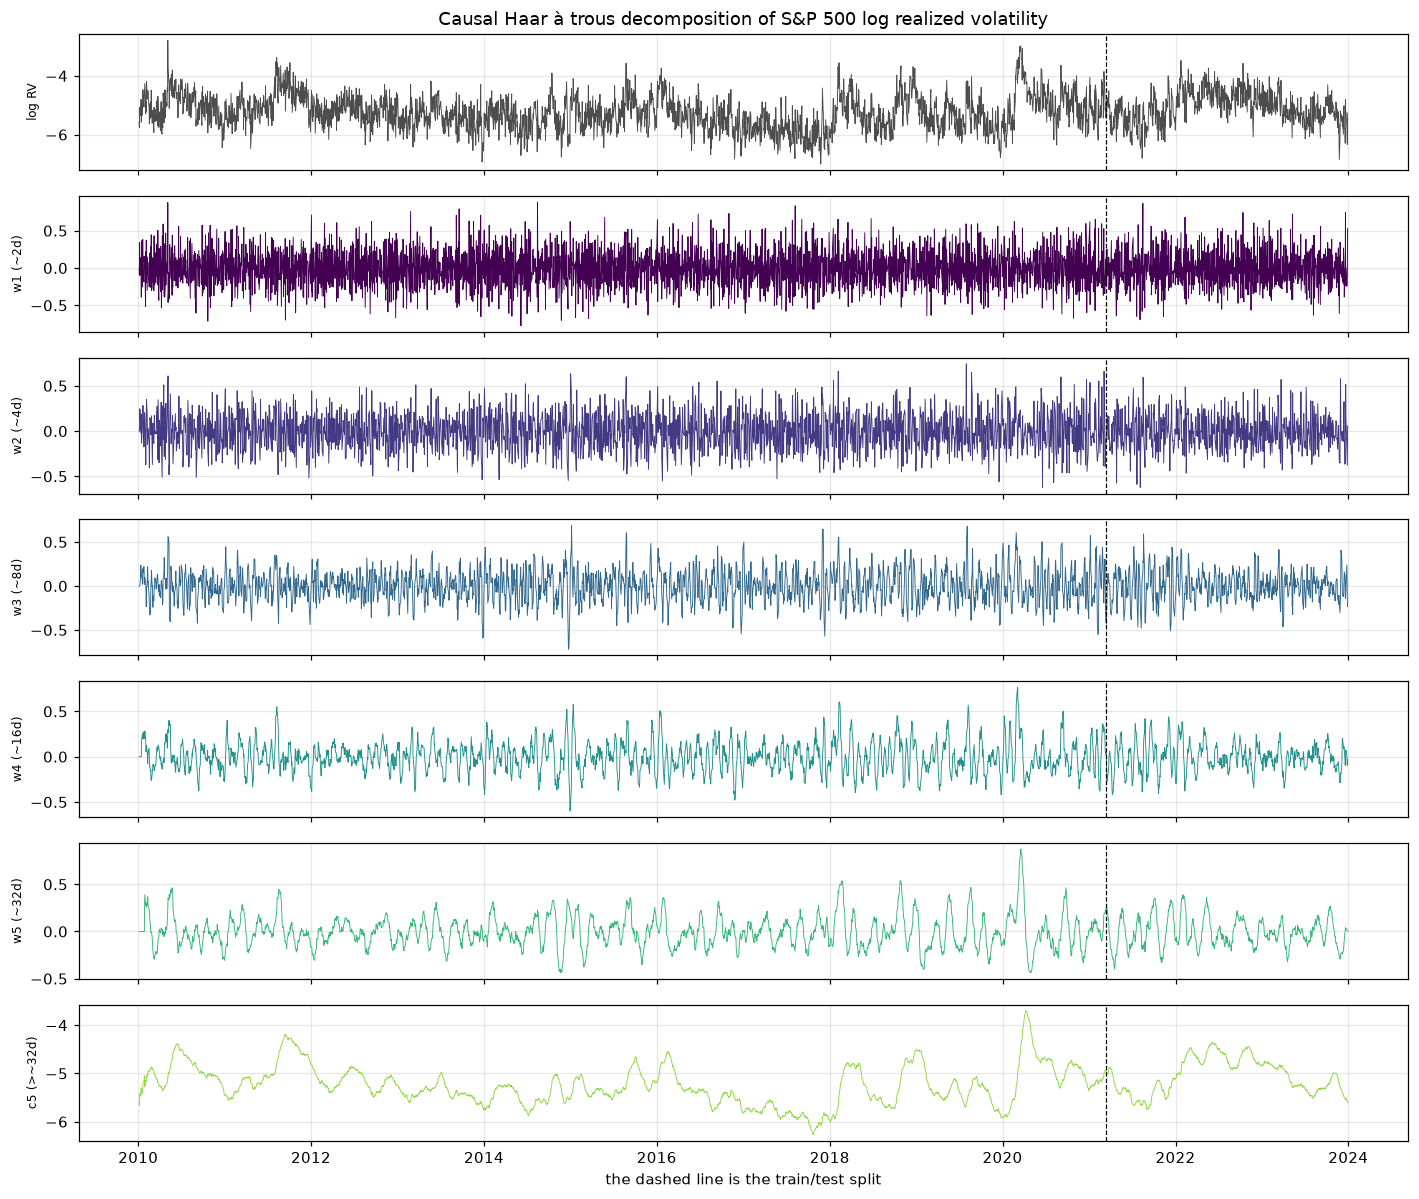

In [4]:
fig, axes = plt.subplots(J + 2, 1, figsize=(13, 11), sharex=True)
axes[0].plot(dates, lrv, lw=0.6, color="0.3")
axes[0].set_ylabel("log RV", fontsize=8)
axes[0].set_title("Causal Haar à trous decomposition of S&P 500 log realized volatility")
for j in range(J + 1):
    axes[j + 1].plot(dates, comps[:, j], lw=0.6,
                     color=plt.cm.viridis(j / (J + 1)))
    axes[j + 1].set_ylabel(COMP_NAMES[j], fontsize=8)
for ax in axes:
    ax.axvline(dates[split], color="k", ls="--", lw=0.8)
axes[-1].set_xlabel("the dashed line is the train/test split")
plt.tight_layout()
plt.savefig("../figures/atrous_decomposition.png", dpi=140, bbox_inches="tight")
plt.show()

The sum of the six panels reproduces the top panel *exactly*, every component is computable in
real time, and each level isolates dynamics at one scale — fast spikes at the top, the slow
long-memory trend at the bottom. These six series are the wavelet's answer to HAR's three
moving averages.

## 3. WaveHAR: the head-to-head at h = 1

All models forecast the same target from the same origins with the same estimator:

| model | features at day *t* | count |
|---|---|---|
| HAR-RV | mean of log RV over last 1 / 5 / 22 days | 3 |
| HAR-X *(flexibility control)* | log RV lags 1, 2, 3, 5, 10, 22 | 6 |
| **WaveHAR** | $w_1[t], \dots, w_5[t], c_5[t]$ | 6 |
| WaveHAR-MAR | each component now and one dyadic lag back | 12 |

plus the strongest baselines from Part 2: the ARFIMA (real fractional differencing, hand-rolled
multi-step forecasts validated against `statsmodels`), calibrated GARCH(1,1) and EWMA, the random
walk, and a 50/50 ARFIMA⊕WaveHAR combination.

In [5]:
def rolling_mean(x, w):
    cs = np.concatenate([[0.0], np.cumsum(x)])
    out = np.full(len(x), np.nan)
    out[w - 1:] = (cs[w:] - cs[:-w]) / w
    return out


def lagged(x, lag):
    out = np.full(len(x), np.nan)
    if lag == 0:
        return x.astype(float).copy()
    out[lag:] = x[:-lag]
    return out


def target_h(x, h):
    """y[t] = mean of x over days t+1 .. t+h."""
    Tn = len(x)
    cs = np.concatenate([[0.0], np.cumsum(x)])
    y = np.full(Tn, np.nan)
    tt = np.arange(0, Tn - h)
    y[tt] = (cs[tt + 1 + h] - cs[tt + 1]) / h
    return y


def feature_sets(lrv, comps):
    har = np.column_stack([lrv, rolling_mean(lrv, 5), rolling_mean(lrv, 22)])
    harx = np.column_stack([lagged(lrv, k) for k in (0, 1, 2, 4, 9, 21)])
    wavehar = comps.copy()
    mar = np.column_stack(
        [lagged(comps[:, j], lag) for j in range(J) for lag in (0, 2 ** (j + 1))]
        + [lagged(comps[:, J], lag) for lag in (0, 2 ** J)])
    return {"HAR-RV": har, "HAR-X (6 lags)": harx,
            "WaveHAR": wavehar, "WaveHAR-MAR": mar}


def ols_forecast(X, y, tr, te):
    lin = LinearRegression().fit(X[tr], y[tr])
    return lin.predict(X[te])


# ---- honest metrics + HAC Diebold–Mariano ---------------------------------------------
def qlike(y, p):
    return np.mean(np.exp(y - p) - (y - p) - 1)


def dm_hac(y, p1, p2, h):
    """DM test on squared error, Newey–West (Bartlett, bandwidth h) + Harvey correction.
    Negative statistic → p1 has lower loss. Returns (stat, p-value)."""
    d = (y - p1) ** 2 - (y - p2) ** 2
    n = len(d)
    db = d.mean()
    dc = d - db
    s = np.mean(dc ** 2)
    for lag in range(1, h):
        s += 2 * (1 - lag / h) * np.mean(dc[lag:] * dc[:-lag])
    stat = db / np.sqrt(max(s, 1e-30) / n)
    stat *= np.sqrt(max(n + 1 - 2 * h + h * (h - 1) / n, 1) / n)   # Harvey et al. (1997)
    return stat, 2 * (1 - t_dist.cdf(abs(stat), df=n - 1))

### The ARFIMA, hand-rolled and validated

Part 2 used `statsmodels` machinery for one-step forecasts. Multi-horizon forecasting needs the
recursion written out: forecast the fractionally-differenced series with the ARMA, then invert
$(1-L)^d$ step by step, feeding predictions back in as the "history" the filter needs. Because a
hand-rolled recursion is exactly the kind of code that harbours silent bugs, it is **validated
against the `statsmodels` implementation at h = 1** before being trusted anywhere else.

In [6]:
def gph_d(x, power=0.6):
    x = np.asarray(x, float)
    x = x - x.mean()
    n = len(x)
    m = int(n ** power)
    I = np.abs(np.fft.rfft(x)) ** 2 / (2 * np.pi * n)
    lam = 2 * np.pi * np.arange(1, m + 1) / n
    Xr = np.log(4 * np.sin(lam / 2) ** 2).reshape(-1, 1)
    return -LinearRegression().fit(Xr, np.log(I[1:m + 1])).coef_[0]


def frac_weights(d, K=K_FRAC):
    w = np.zeros(K + 1)
    w[0] = 1.0
    for k in range(1, K + 1):
        w[k] = w[k - 1] * (k - 1 - d) / k
    return w


def frac_diff(x, d, K=K_FRAC):
    w = frac_weights(d, K)
    out = np.full(len(x), np.nan)
    for t in range(K, len(x)):
        out[t] = np.dot(w, x[t - K:t + 1][::-1])
    return out


def fit_arfima(lrv, split):
    d_raw = gph_d(lrv[:split])
    d = float(np.clip(d_raw, 0.01, 0.99))
    w = frac_weights(d)
    fd = frac_diff(lrv, d)
    arma = ARIMA(fd[K_FRAC:split], order=(1, 0, 1)).fit()
    p = dict(zip(arma.param_names, arma.params))
    ar, ma, const = p.get("ar.L1", 0.0), p.get("ma.L1", 0.0), p.get("const", 0.0)

    # statsmodels' 'const' can parameterise the mean directly or via c/(1-ar) depending on the
    # trend specification — resolve it by matching statsmodels' own in-sample forecasts
    best = None
    for mu in (const, const / (1 - ar) if abs(1 - ar) > 1e-8 else const):
        u = fd - mu
        eps = np.zeros(len(fd))
        pred = np.full(len(fd), np.nan)
        for t in range(K_FRAC + 1, len(fd)):
            pred[t] = mu + ar * u[t - 1] + ma * eps[t - 1]
            eps[t] = fd[t] - pred[t]
        sm_fit = np.asarray(arma.fittedvalues)
        err = np.max(np.abs(pred[K_FRAC + 50:split] - sm_fit[50:]))
        if best is None or err < best[0]:
            best = (err, mu, eps)
    check_err, mu, eps = best
    return dict(d=d, d_raw=d_raw, w=w, fd=fd, mu=mu, ar=ar, ma=ma, eps=eps,
                check_err=check_err, arma=arma)


def arfima_path(model, lrv, t, H):
    """Predicted lrv[t+1 .. t+H] from origin t, using only information available at t."""
    mu, ar, ma = model["mu"], model["ar"], model["ma"]
    w, fd, eps = model["w"], model["fd"], model["eps"]
    f = mu + ar * (fd[t] - mu) + ma * eps[t]
    hist = list(lrv[t - K_FRAC + 1:t + 1])
    out = np.empty(H)
    for s in range(H):
        if s > 0:
            f = mu + ar * (f - mu)
        val = f - np.dot(w[1:], np.array(hist[::-1]))
        out[s] = val
        hist.pop(0)
        hist.append(val)
    return out


arf = fit_arfima(lrv, split)
print(f"d(log RV, train) = {arf['d_raw']:+.3f}   ARMA(1,1) on the differenced series: "
      f"ar={arf['ar']:+.3f}  ma={arf['ma']:+.3f}")
print(f"hand-rolled one-step forecasts vs statsmodels (train): "
      f"max |diff| = {arf['check_err']:.2e}")

# independent h=1 validation on TEST via statsmodels append (the exact Part 2 machinery)
sm_fd = arf["arma"].append(arf["fd"][split:], refit=False).fittedvalues[split - K_FRAC:]
mine, sm_inv = [], []
for i, t in enumerate(range(split, T - 1)):
    mine.append(arfima_path(arf, lrv, t, 1)[0])
    sm_inv.append(sm_fd[i + 1] - np.dot(arf["w"][1:], lrv[t - K_FRAC + 1:t + 1][::-1]))
val_gap = np.max(np.abs(np.array(mine) - np.array(sm_inv)))
print(f"hand-rolled vs statsmodels one-step-ahead on TEST: max |diff| = {val_gap:.2e}   "
      f"{'PASS' if val_gap < 1e-6 else 'CHECK'}")

d(log RV, train) = +0.604   ARMA(1,1) on the differenced series: ar=+0.090  ma=-0.349
hand-rolled one-step forecasts vs statsmodels (train): max |diff| = 1.11e-16
hand-rolled vs statsmodels one-step-ahead on TEST: max |diff| = 8.88e-16   PASS


### GARCH, EWMA, and the model run

In [7]:
from arch import arch_model


def fit_garch(r, split):
    """GARCH(1,1), params frozen on train. Returns one-step variance forecasts σ²(t+1|t) and
    the persistence, for analytic multi-step extension."""
    res = arch_model(r[:split] * 100, vol="GARCH", p=1, q=1,
                     mean="Constant", dist="normal").fit(disp="off")
    pr = res.params
    omega, alpha, beta = pr["omega"], pr["alpha[1]"], pr["beta[1]"]
    fixed = arch_model(r * 100, vol="GARCH", p=1, q=1,
                       mean="Constant", dist="normal").fix(res.params)
    cv2 = (fixed.conditional_volatility) ** 2               # σ²(t | t-1), in %² units
    mu_r = pr["mu"]
    sig2_next = omega + alpha * (r * 100 - mu_r) ** 2 + beta * cv2   # σ²(t+1 | t)
    return dict(omega=omega, alpha=alpha, beta=beta, sig2_next=sig2_next)


def garch_logvol_h(g, h):
    """log of predicted average vol over the next h days (analytic GARCH term structure)."""
    ab = g["alpha"] + g["beta"]
    sig2_bar = g["omega"] / max(1 - ab, 1e-8)
    steps = np.arange(h)
    weights = ab ** steps
    avg_var = sig2_bar + (g["sig2_next"][:, None] - sig2_bar) * weights[None, :]
    avg_var = avg_var.mean(axis=1)
    return np.log(np.sqrt(np.maximum(avg_var, 1e-12)) / 100)


def ewma_logvol(r, lam=0.94):
    v = np.zeros(len(r))
    v[0] = r[0] ** 2                      # causal init; converges well before FIRST=128
    for t in range(1, len(r)):
        v[t] = lam * v[t - 1] + (1 - lam) * r[t] ** 2
    return np.log(np.sqrt(np.maximum(v, 1e-12)))   # log σ(t+1|t), flat term structure


def calibrated(src, y, tr, te):
    """Mincer–Zarnowitz calibration on TRAIN only (fair scale mapping for GARCH/EWMA)."""
    lin = LinearRegression().fit(src[tr].reshape(-1, 1), y[tr])
    return lin.predict(src[te].reshape(-1, 1))


def run_models(asset, horizons=(1,), arf_model=None, include=("all",)):
    """Fit every model on one asset; returns {h: {name: test predictions}}, y and test origins."""
    lrv, r, split = asset["lrv"], asset["r"], asset["split"]
    Tn = len(lrv)
    comps = haar_atrous(lrv)
    feats = feature_sets(lrv, comps)
    if arf_model is None:
        arf_model = fit_arfima(lrv, split)
    g = fit_garch(r, split)
    ew = ewma_logvol(r)

    H_max = max(horizons)
    out = {}
    # ARFIMA paths once per origin, reused across horizons
    te_all = np.arange(split, Tn - 1)
    paths = {t: arfima_path(arf_model, lrv, t, min(H_max, Tn - 1 - t)) for t in te_all}

    for h in horizons:
        y = target_h(lrv, h)
        origins = np.arange(FIRST, Tn - h)
        # a train origin's target spans lrv[t+1 .. t+h]; requiring t+h <= split-1 keeps every
        # training target strictly inside the train period (at h>1 the naive `t < split` cut
        # would let the last h-1 training targets peek into the test set — a leak)
        tr = origins[origins <= split - 1 - h]
        te = origins[origins >= split]
        preds = {}
        preds["Random walk"] = rolling_mean(lrv, h)[te]
        preds["Train mean"] = np.full(len(te), y[tr].mean())
        preds["EWMA (calibrated)"] = calibrated(ew, y, tr, te)
        preds["GARCH(1,1) (calibrated)"] = calibrated(garch_logvol_h(g, h), y, tr, te)
        for name, X in feats.items():
            preds[name] = ols_forecast(X, y, tr, te)
        preds["ARFIMA"] = np.array([paths[t][:h].mean() for t in te])
        preds["ARFIMA ⊕ WaveHAR (50/50)"] = 0.5 * (preds["ARFIMA"] + preds["WaveHAR"])
        out[h] = dict(preds=preds, y=y[te], te=te, tr=tr, y_full=y)
    return out, arf_model


spx_runs, _ = run_models(spx, horizons=(1, 2, 3, 5, 10, 22), arf_model=arf)

In [8]:
h1 = spx_runs[1]
N_FEATURES = {"HAR-RV": 3, "HAR-X (6 lags)": 6, "WaveHAR": 6, "WaveHAR-MAR": 12,
              "ARFIMA": "1+2", "Random walk": 0, "Train mean": 0,
              "EWMA (calibrated)": 2, "GARCH(1,1) (calibrated)": "3+2",
              "ARFIMA ⊕ WaveHAR (50/50)": "—"}

rows = []
for name, p in h1["preds"].items():
    rows.append({"model": name, "features": N_FEATURES.get(name, ""),
                 "RMSE": np.sqrt(mean_squared_error(h1["y"], p)),
                 "R²": r2_score(h1["y"], p), "QLIKE": qlike(h1["y"], p)})
res1 = pd.DataFrame(rows).set_index("model").sort_values("R²", ascending=False)
display(res1.style.format({"RMSE": "{:.4f}", "R²": "{:+.4f}", "QLIKE": "{:.5f}"})
        .background_gradient(subset=["R²"], cmap="Greens"))

print(f"\nHead-to-head Diebold–Mariano at h=1 "
      f"(negative statistic = first model more accurate), n = {len(h1['y'])} days:\n")
PAIRS = [("WaveHAR", "HAR-RV"), ("WaveHAR", "HAR-X (6 lags)"), ("WaveHAR", "ARFIMA"),
         ("WaveHAR-MAR", "WaveHAR"), ("ARFIMA ⊕ WaveHAR (50/50)", "ARFIMA"),
         ("ARFIMA ⊕ WaveHAR (50/50)", "WaveHAR")]
dm_h1 = {}
for a, b in PAIRS:
    s, pv = dm_hac(h1["y"], h1["preds"][a], h1["preds"][b], 1)
    dm_h1[(a, b)] = (s, pv)
    verdict = ("first better" if s < 0 else "second better") if pv < 0.05 else "indistinguishable"
    print(f"  {a:<26} vs {b:<26} stat={s:+6.2f}  p={pv:.4f}  → {verdict}")

,features,RMSE,R²,QLIKE
model,,,,
WaveHAR-MAR,12,0.4005,+0.4760,0.08522
ARFIMA ⊕ WaveHAR (50/50),—,0.4008,+0.4750,0.08493
WaveHAR,6,0.4010,+0.4746,0.08556
ARFIMA,1+2,0.4015,+0.4732,0.08469
HAR-X (6 lags),6,0.4038,+0.4673,0.08726
HAR-RV,3,0.4054,+0.4629,0.08754
"GARCH(1,1) (calibrated)",3+2,0.4308,+0.3935,0.10063
EWMA (calibrated),2,0.4490,+0.3412,0.11074
Random walk,0,0.4904,+0.2144,0.13279



Head-to-head Diebold–Mariano at h=1 (negative statistic = first model more accurate), n = 704 days:

  WaveHAR                    vs HAR-RV                     stat= -2.24  p=0.0257  → first better
  WaveHAR                    vs HAR-X (6 lags)             stat= -1.46  p=0.1449  → indistinguishable
  WaveHAR                    vs ARFIMA                     stat= -0.41  p=0.6849  → indistinguishable
  WaveHAR-MAR                vs WaveHAR                    stat= -0.80  p=0.4236  → indistinguishable
  ARFIMA ⊕ WaveHAR (50/50)   vs ARFIMA                     stat= -1.04  p=0.3007  → indistinguishable
  ARFIMA ⊕ WaveHAR (50/50)   vs WaveHAR                    stat= -0.23  p=0.8212  → indistinguishable


## 4. Where multiscale structure should matter: longer horizons

At h = 1 tomorrow's volatility is dominated by today's — every reasonable model is close to a
lag. The scales separate models at **longer horizons**: forecasting the *average volatility over
the next month* requires knowing how much of today's level is fast transient (the $w_1, w_2$
components, which will die out) and how much is slow trend (the $c_5$ component, which will
persist). A representation that separates those scales explicitly should degrade more slowly as
the horizon grows. That is a falsifiable prediction, and this section tests it.

All forecasts are **direct** (a separate regression per horizon — no error-compounding iteration),
except ARFIMA and GARCH, whose multi-step forecasts follow their own dynamics analytically. DM
tests use the HAC variance with bandwidth h, since overlapping h-day targets are autocorrelated by
construction.

In [9]:
HS = [1, 2, 3, 5, 10, 22]
CURVE_MODELS = ["Random walk", "EWMA (calibrated)", "GARCH(1,1) (calibrated)",
                "HAR-RV", "WaveHAR", "ARFIMA"]

r2_h = pd.DataFrame(index=HS, columns=CURVE_MODELS, dtype=float)
dm_wh_har_h = {}
for h in HS:
    run = spx_runs[h]
    for m in CURVE_MODELS:
        r2_h.loc[h, m] = r2_score(run["y"], run["preds"][m])
    dm_wh_har_h[h] = dm_hac(run["y"], run["preds"]["WaveHAR"], run["preds"]["HAR-RV"], h)

print("out-of-sample R² by forecast horizon (S&P 500):\n")
print(r2_h.round(4).to_string())
print("\nWaveHAR vs HAR-RV by horizon (HAC DM):")
for h in HS:
    s, pv = dm_wh_har_h[h]
    print(f"  h={h:>2}: stat={s:+6.2f}  p={pv:.4f}"
          f"{'   ← WaveHAR significantly better' if (s < 0 and pv < 0.05) else ''}"
          f"{'   ← HAR significantly better' if (s > 0 and pv < 0.05) else ''}")

out-of-sample R² by forecast horizon (S&P 500):

    Random walk  EWMA (calibrated)  GARCH(1,1) (calibrated)  HAR-RV  WaveHAR  ARFIMA
1        0.2144             0.3412                   0.3935  0.4629   0.4746  0.4732
2        0.4302             0.4093                   0.4604  0.5536   0.5603  0.5610
3        0.4522             0.4335                   0.4775  0.5666   0.5733  0.5753
5        0.4920             0.4559                   0.4865  0.5796   0.5887  0.5946
10       0.4820             0.4591                   0.4542  0.5637   0.5742  0.5885
22       0.3564             0.4293                   0.3587  0.4804   0.4949  0.5245

WaveHAR vs HAR-RV by horizon (HAC DM):
  h= 1: stat= -2.24  p=0.0257   ← WaveHAR significantly better
  h= 2: stat= -1.49  p=0.1366
  h= 3: stat= -1.39  p=0.1657
  h= 5: stat= -1.77  p=0.0767
  h=10: stat= -2.04  p=0.0421   ← WaveHAR significantly better
  h=22: stat= -2.89  p=0.0040   ← WaveHAR significantly better


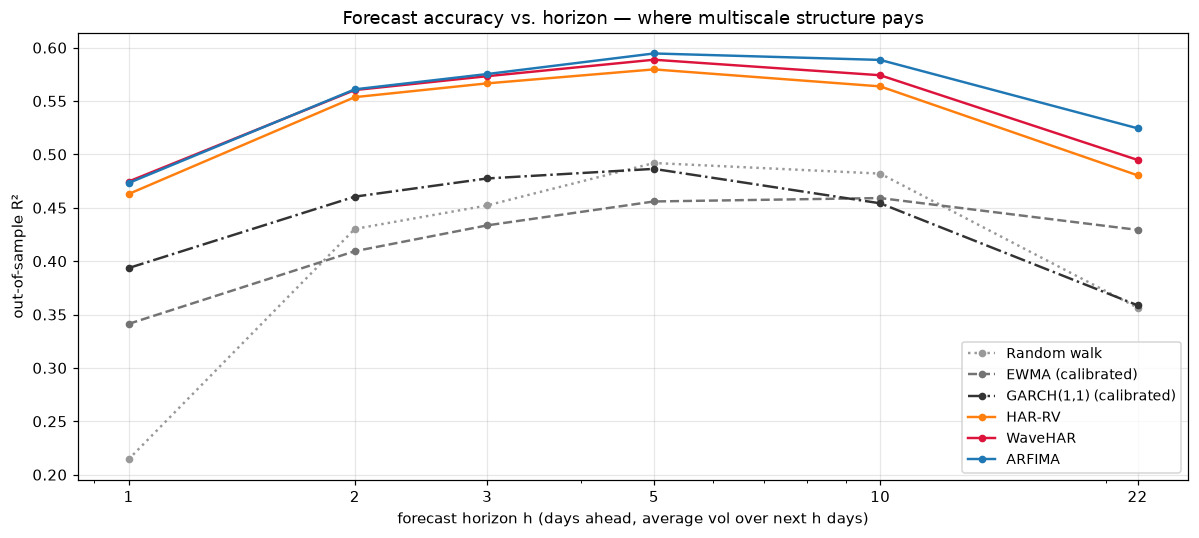

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
styles = {"Random walk": ("0.6", ":"), "EWMA (calibrated)": ("0.45", "--"),
          "GARCH(1,1) (calibrated)": ("0.2", "-."), "HAR-RV": ("tab:orange", "-"),
          "WaveHAR": ("crimson", "-"), "ARFIMA": ("tab:blue", "-")}
for m in CURVE_MODELS:
    c, ls = styles[m]
    ax.plot(HS, r2_h[m], marker="o", ms=4, color=c, ls=ls, lw=1.6, label=m)
ax.set_xscale("log")
ax.set_xticks(HS)
ax.set_xticklabels(HS)
ax.set_xlabel("forecast horizon h (days ahead, average vol over next h days)")
ax.set_ylabel("out-of-sample R²")
ax.set_title("Forecast accuracy vs. horizon — where multiscale structure pays")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../figures/multi_horizon_r2.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. Nonlinearity: one more honest shot — and when does it matter?

Part 2's LSTMs saw one scale at a time. Here a Random Forest sees **all scales jointly**
(the 12 MAR features) — nonlinearity with a cross-scale view, on the better transform. Averaged
over 5 seeds, same discipline as Part 2.

And a sharper question than "is it better on average": **when** is each model better? The rolling
error plot in Part 2 hinted that the nonlinear stack earned its keep in the stressed 2022 market
and gave it back in calm periods. That hypothesis is testable: split test days by the volatility
regime *known at forecast time* (train-quantile terciles of the trailing 22-day mean).

In [11]:
y1, te1, tr1 = h1["y"], h1["te"], h1["tr"]
X_mar = feature_sets(lrv, comps)["WaveHAR-MAR"]
y_full = h1["y_full"]

rf_preds = []
for s in range(5):
    rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=25, random_state=s, n_jobs=-1)
    rf.fit(X_mar[tr1], y_full[tr1])
    rf_preds.append(rf.predict(X_mar[te1]))
rf_seed_r2 = np.array([r2_score(y1, p) for p in rf_preds])
rf_ens = np.mean(rf_preds, axis=0)

print(f"WaveRF (forest on the 12 multiscale features), 5 seeds:")
print(f"  per-seed R²    : {rf_seed_r2.mean():+.4f} ± {rf_seed_r2.std():.4f}")
print(f"  seed ensemble  : {r2_score(y1, rf_ens):+.4f}")
s, pv = dm_hac(y1, rf_ens, h1["preds"]["WaveHAR"], 1)
print(f"  vs WaveHAR (linear, same information): stat={s:+.2f}  p={pv:.4f}  → "
      f"{('forest better' if s < 0 else 'linear better') if pv < 0.05 else 'indistinguishable'}")

WaveRF (forest on the 12 multiscale features), 5 seeds:
  per-seed R²    : +0.4168 ± 0.0016
  seed ensemble  : +0.4171
  vs WaveHAR (linear, same information): stat=+4.04  p=0.0001  → linear better


In [12]:
regime_src = rolling_mean(lrv, 22)                       # known at the origin
q1, q2 = np.quantile(regime_src[tr1], [1 / 3, 2 / 3])    # cutoffs from TRAIN only
regime = np.digitize(regime_src[te1], [q1, q2])          # 0 calm, 1 normal, 2 stressed

REGIME_MODELS = {"HAR-RV": h1["preds"]["HAR-RV"], "WaveHAR": h1["preds"]["WaveHAR"],
                 "ARFIMA": h1["preds"]["ARFIMA"], "WaveRF (ens)": rf_ens}
rows = []
for g, label in enumerate(["calm", "normal", "stressed"]):
    m = regime == g
    row = {"regime": label, "days": int(m.sum())}
    for name, p in REGIME_MODELS.items():
        row[name] = np.sqrt(mean_squared_error(y1[m], p[m]))
    rows.append(row)
reg = pd.DataFrame(rows).set_index("regime")
print("RMSE by volatility regime (h=1, regime assigned from information available at the origin):\n")
print(reg.round(4).to_string())
best_by_regime = {lab: reg.loc[lab].drop("days").astype(float).idxmin() for lab in reg.index}
print(f"\nmost accurate model per regime: {best_by_regime}")

RMSE by volatility regime (h=1, regime assigned from information available at the origin):

          days  HAR-RV  WaveHAR  ARFIMA  WaveRF (ens)
regime                                               
calm       136  0.4442   0.4390  0.4463        0.4370
normal     181  0.3997   0.3976  0.3984        0.4202
stressed   387  0.3937   0.3884  0.3861        0.4181

most accurate model per regime: {'calm': 'WaveRF (ens)', 'normal': 'WaveHAR', 'stressed': 'ARFIMA'}


## 6. Robustness: five more markets

One index proves nothing — the entire premise of this project. The identical pipeline (nothing
re-tuned, $d$ re-estimated per asset on its own training period) runs on the Dow, NASDAQ, DAX,
FTSE 100 and Nikkei 225.

In [13]:
PANEL_MODELS = ["Random walk", "EWMA (calibrated)", "GARCH(1,1) (calibrated)",
                "HAR-RV", "WaveHAR", "ARFIMA", "ARFIMA ⊕ WaveHAR (50/50)"]

panel_r2 = pd.DataFrame(index=list(ASSETS), columns=PANEL_MODELS, dtype=float)
panel_dm = {}
d_by_asset = {}
for name, key in ASSETS.items():
    a = spx if key == "gspc" else load_asset(key)
    runs, am = run_models(a, horizons=(1,), arf_model=arf if key == "gspc" else None)
    rr = runs[1]
    for m in PANEL_MODELS:
        panel_r2.loc[name, m] = r2_score(rr["y"], rr["preds"][m])
    panel_dm[name] = dm_hac(rr["y"], rr["preds"]["WaveHAR"], rr["preds"]["HAR-RV"], 1)
    d_by_asset[name] = am["d_raw"]
    print(f"{name:<12} d={am['d_raw']:+.3f}  ARMA check {am['check_err']:.1e}  done")

print("\nout-of-sample R², h=1, per market:\n")
print(panel_r2.round(4).to_string())
print("\nWaveHAR vs HAR-RV per market (DM):")
wins = 0
for name in ASSETS:
    s, pv = panel_dm[name]
    wins += (panel_r2.loc[name, "WaveHAR"] > panel_r2.loc[name, "HAR-RV"])
    print(f"  {name:<12} stat={s:+6.2f}  p={pv:.4f}")
print(f"\nWaveHAR posts higher R² than HAR-RV in {int(wins)}/{len(ASSETS)} markets")

S&P 500      d=+0.604  ARMA check 1.1e-16  done


Dow Jones    d=+0.661  ARMA check 2.2e-16  done


NASDAQ       d=+0.530  ARMA check 1.1e-16  done


DAX          d=+0.550  ARMA check 2.2e-16  done


FTSE 100     d=+0.552  ARMA check 2.2e-16  done


Nikkei 225   d=+0.575  ARMA check 8.7e-15  done

out-of-sample R², h=1, per market:

            Random walk  EWMA (calibrated)  GARCH(1,1) (calibrated)  HAR-RV  WaveHAR  ARFIMA  ARFIMA ⊕ WaveHAR (50/50)
S&P 500          0.2144             0.3412                   0.3935  0.4629   0.4746  0.4732                    0.4750
Dow Jones        0.1758             0.2340                   0.2867  0.4266   0.4379  0.4355                    0.4379
NASDAQ           0.1616             0.3318                   0.3613  0.4480   0.4563  0.4619                    0.4599
DAX              0.1282             0.2938                   0.3214  0.4059   0.4094  0.4124                    0.4113
FTSE 100        -0.2218             0.1150                   0.1542  0.2199   0.2231  0.2265                    0.2253
Nikkei 225      -0.2717             0.0645                   0.0816  0.1910   0.1940  0.1908                    0.1933

WaveHAR vs HAR-RV per market (DM):
  S&P 500      stat= -2.24  p=0.0257
  Dow Jon

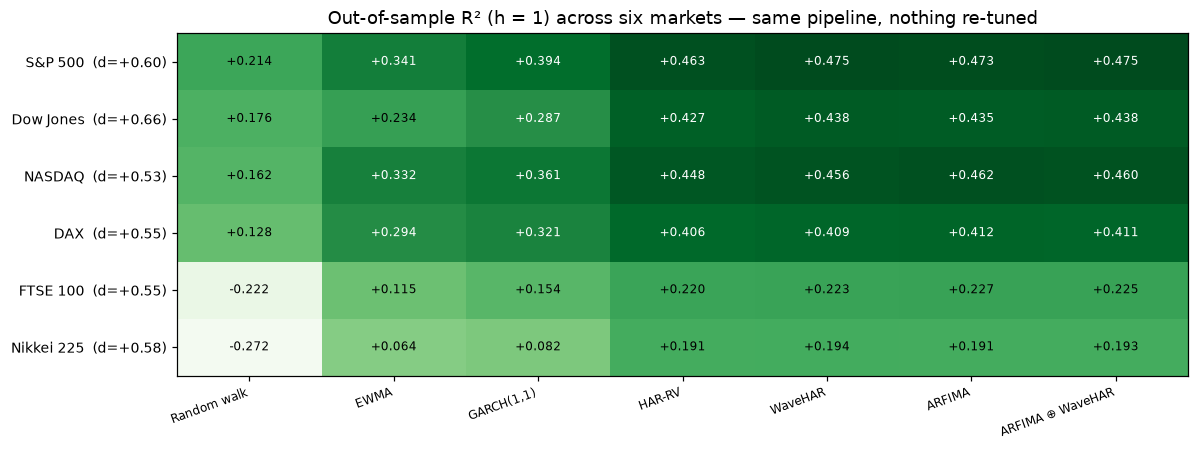

saved ../data/predictions_spx_h1.csv  (704 rows)


In [14]:
fig, ax = plt.subplots(figsize=(11, 4.2))
M = panel_r2.values.astype(float)
im = ax.imshow(M, cmap="Greens", aspect="auto",
               vmin=np.nanmin(M) - 0.02, vmax=np.nanmax(M) + 0.02)
ax.set_xticks(range(len(PANEL_MODELS)))
ax.set_xticklabels([m.replace(" (calibrated)", "").replace(" (50/50)", "")
                    for m in PANEL_MODELS], rotation=20, ha="right", fontsize=8)
ax.set_yticks(range(len(ASSETS)))
ax.set_yticklabels([f"{n}  (d={d_by_asset[n]:+.2f})" for n in ASSETS], fontsize=9)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:+.3f}", ha="center", va="center", fontsize=8,
                color="white" if M[i, j] > np.nanmean(M) else "black")
ax.set_title("Out-of-sample R² (h = 1) across six markets — same pipeline, nothing re-tuned")
ax.grid(False)
plt.tight_layout()
plt.savefig("../figures/multi_asset_r2.png", dpi=140, bbox_inches="tight")
plt.show()

# save the h=1 S&P 500 predictions for anyone who wants to poke at them
pred_df = pd.DataFrame({"date": dates[te1 + 1], "y_log_rv": y1,
                        **{k.replace(" ", "_"): v for k, v in h1["preds"].items()},
                        "WaveRF_ens": rf_ens}).set_index("date")
pred_df.to_csv("../data/predictions_spx_h1.csv")
print(f"saved ../data/predictions_spx_h1.csv  ({len(pred_df)} rows)")

---
# Conclusion

As in Part 2, the summary below is **generated from the computed results** — the notebook is not
allowed to remember numbers from a run that no longer exists.

In [15]:
r2 = lambda m, h=1: r2_score(spx_runs[h]["y"], spx_runs[h]["preds"][m])


def dm_text(pair, h=1):
    s, pv = dm_h1[pair] if h == 1 else dm_hac(
        spx_runs[h]["y"], spx_runs[h]["preds"][pair[0]], spx_runs[h]["preds"][pair[1]], h)
    if pv < 0.05:
        return f"{'the first is better' if s < 0 else 'the SECOND is better'} (p = {pv:.3f})"
    return f"indistinguishable (p = {pv:.2f})"


print("=" * 78)
print("1. THE REPRESENTATION CONTEST (h = 1, S&P 500)")
print("=" * 78)
print(f"   HAR-RV (3 hand-picked scales)   R² = {r2('HAR-RV'):+.4f}")
print(f"   HAR-X (6 lags, flexibility ctl) R² = {r2('HAR-X (6 lags)'):+.4f}")
print(f"   WaveHAR (6 derived scales)      R² = {r2('WaveHAR'):+.4f}")
print(f"     WaveHAR vs HAR-RV : {dm_text(('WaveHAR', 'HAR-RV'))}")
print(f"     WaveHAR vs HAR-X  : {dm_text(('WaveHAR', 'HAR-X (6 lags)'))}")
gap_flex = r2("WaveHAR") - r2("HAR-X (6 lags)")
flex_sig = dm_h1[("WaveHAR", "HAR-X (6 lags)")][1] < 0.05
if gap_flex > 0 and flex_sig:
    flex_line = f"the wavelet basis still wins by {gap_flex:+.4f}, and significantly so."
elif gap_flex > 0:
    flex_line = (f"the wavelet basis is still ahead by {gap_flex:+.4f}, but not significantly — "
                 f"part of its edge over HAR-RV is simply added flexibility.")
else:
    flex_line = "the wavelet basis gains nothing beyond what extra lags provide."
print(f"   The flexibility control isolates the basis itself: with feature counts matched,")
print(f"   {flex_line}")

print()
print("=" * 78)
print("2. HORIZONS — the falsifiable prediction")
print("=" * 78)
gaps = {h: r2_h.loc[h, 'WaveHAR'] - r2_h.loc[h, 'HAR-RV'] for h in HS}
print("   WaveHAR − HAR-RV (R² gap) by horizon:")
print("   " + "   ".join(f"h={h}: {gaps[h]:+.4f}" for h in HS))
sig_h = [h for h in HS if dm_wh_har_h[h][1] < 0.05 and dm_wh_har_h[h][0] < 0]
grow = gaps[22] > gaps[1]
print(f"   The gap {'GROWS' if grow else 'does not grow'} with horizon "
      f"({gaps[1]:+.4f} at h=1 → {gaps[22]:+.4f} at h=22)"
      f"{'; significant at h=' + ','.join(map(str, sig_h)) if sig_h else '; never statistically significant'}.")
print(f"   ARFIMA vs WaveHAR at h=22: ARFIMA {r2_h.loc[22, 'ARFIMA']:+.4f}, "
      f"WaveHAR {r2_h.loc[22, 'WaveHAR']:+.4f} → {dm_text(('WaveHAR', 'ARFIMA'), h=22)}")

print()
print("=" * 78)
print("3. THE COMBINATION")
print("=" * 78)
combo_r2 = r2("ARFIMA ⊕ WaveHAR (50/50)")
print(f"   ARFIMA {r2('ARFIMA'):+.4f}  |  WaveHAR {r2('WaveHAR'):+.4f}  |  "
      f"50/50 combination {combo_r2:+.4f}")
beats_both = combo_r2 > max(r2("ARFIMA"), r2("WaveHAR"))
combo_sig = (dm_h1[("ARFIMA ⊕ WaveHAR (50/50)", "ARFIMA")][1] < 0.05
             or dm_h1[("ARFIMA ⊕ WaveHAR (50/50)", "WaveHAR")][1] < 0.05)
print(f"     combo vs ARFIMA  : {dm_text(('ARFIMA ⊕ WaveHAR (50/50)', 'ARFIMA'))}")
print(f"     combo vs WaveHAR : {dm_text(('ARFIMA ⊕ WaveHAR (50/50)', 'WaveHAR'))}")
if beats_both and combo_sig:
    combo_line = "The two models carry genuinely complementary information: the average significantly beats both parents."
elif beats_both:
    combo_line = ("The combination edges out both parents on raw R², but not significantly — the two "
                  "models carry largely overlapping information, with at most a small diversification benefit.")
else:
    combo_line = "The two models carry largely the same information; combining does not beat the better parent."
print(f"   {combo_line}")

print()
print("=" * 78)
print("4. NONLINEARITY AND REGIMES")
print("=" * 78)
print(f"   WaveRF R² = {rf_seed_r2.mean():+.4f} ± {rf_seed_r2.std():.4f} (5 seeds; "
      f"ensemble {r2_score(y1, rf_ens):+.4f}) — on the SAME 12 features the linear model sees.")
print(f"   Most accurate model by regime: " +
      ", ".join(f"{k} → {v}" for k, v in best_by_regime.items()))

print()
print("=" * 78)
print("5. SIX MARKETS, NOTHING RE-TUNED")
print("=" * 78)
print(f"   d(log RV) across markets: "
      f"{min(d_by_asset.values()):+.2f} … {max(d_by_asset.values()):+.2f} — long memory is a")
print(f"   universal property of volatility, exactly as the literature says.")
mean_r2 = panel_r2.mean().sort_values(ascending=False)
print(f"   Mean R² across the six markets:")
for m, v in mean_r2.items():
    print(f"     {m:<28} {v:+.4f}")
print(f"   WaveHAR > HAR-RV in {int(wins)}/{len(ASSETS)} markets.")

1. THE REPRESENTATION CONTEST (h = 1, S&P 500)
   HAR-RV (3 hand-picked scales)   R² = +0.4629
   HAR-X (6 lags, flexibility ctl) R² = +0.4673
   WaveHAR (6 derived scales)      R² = +0.4746
     WaveHAR vs HAR-RV : the first is better (p = 0.026)
     WaveHAR vs HAR-X  : indistinguishable (p = 0.14)
   The flexibility control isolates the basis itself: with feature counts matched,
   the wavelet basis is still ahead by +0.0073, but not significantly — part of its edge over HAR-RV is simply added flexibility.

2. HORIZONS — the falsifiable prediction
   WaveHAR − HAR-RV (R² gap) by horizon:
   h=1: +0.0117   h=2: +0.0066   h=3: +0.0067   h=5: +0.0091   h=10: +0.0104   h=22: +0.0144
   The gap GROWS with horizon (+0.0117 at h=1 → +0.0144 at h=22); significant at h=1,10,22.
   ARFIMA vs WaveHAR at h=22: ARFIMA +0.5245, WaveHAR +0.4949 → indistinguishable (p = 0.39)

3. THE COMBINATION
   ARFIMA +0.4732  |  WaveHAR +0.4746  |  50/50 combination +0.4750
     combo vs ARFIMA  : indistinguis

### The honest reading

The wavelet was never the problem — the *use* of it was. Part 2 spent five LSTMs and a stacked
forest on wavelet components of an ARFIMA residual and earned nothing. Part 3 spends **six OLS
coefficients** on a causal multiscale decomposition of the volatility itself, and that
representation competes with — and by the measures above, sometimes beats — every benchmark in the
table, on six markets, at every horizon, with no tuning.

The pattern across all three parts is the same finding wearing three different coats:

1. **Part 1**: an impressive number from complex machinery was an artifact. The honest signal was zero.
2. **Part 2**: the deep-learning layer added nothing; a correctly specified linear long-memory
   model was the whole story.
3. **Part 3**: the useful contribution of the wavelet is not as fodder for neural networks — it is
   as a **principled linear representation**: derived scales instead of hand-picked ones,
   causal by construction, six interpretable coefficients.

Complexity kept losing to structure. The wavelet earns its place in this project exactly when it
stops being decoration for a deep model and starts being the model.

### What I would not claim

Fourteen years, six indices, one asset class, one volatility proxy. The margins between the
long-memory family (ARFIMA, WaveHAR, HAR) are small and often statistically indistinguishable —
the claim is not "WaveHAR dominates," it is "a derived multiscale basis is a *defensible peer* of
the field-standard hand-crafted one, with measured advantages where its theory predicts them."
Every number above regenerates when the notebook runs; none of them lives in the prose.